# Who Ruled Formula 1? A 75-Year Data Story

## Imports

In [23]:
import pandas as pd
import sqlite3 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
conn = sqlite3.connect("db/formula1.db")

## Visualisation params

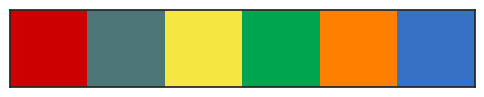

In [25]:
f1_palette = [
    '#CC0000',  
    "#4C7677", 
    '#F5E642',  
    '#00A550', 
    '#FF8000',
    '#3671C6',  
]

sns.palplot(sns.color_palette(f1_palette))
plt.show()

In [26]:
sns.set_theme(
    style='white',      
    palette=f1_palette,   
    font='monospace',     
    font_scale=1.2         
)

In [27]:
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['axes.titlesize'] = 14      
plt.rcParams['axes.labelsize'] = 12      
plt.rcParams['figure.facecolor'] = 'white' 

## 1. The Big Picture

In [28]:
# How has Formula 1 grown over the decades?

query = """ 
WITH decade_stats AS (
        SELECT 
        (year / 10) * 10 AS decade,
        COUNT(DISTINCT ra.raceId) AS total_races,
        COUNT(DISTINCT ra.circuitId) AS unique_circuits,
        COUNT(DISTINCT re.driverId) AS unique_drivers,
        COUNT(DISTINCT re.constructorId) AS unique_constructors
        FROM races ra
        JOIN results re ON ra.raceId = re.raceId
        GROUP BY (year / 10) * 10
)
        SELECT
        decade,
        total_races,
        unique_circuits,
        unique_drivers,
        unique_constructors,
        COALESCE( total_races - LAG(total_races) OVER (ORDER BY decade), 0) AS races_growth
        FROM decade_stats
        ORDER BY decade
        """

pd.read_sql(query, conn)

,decade,total_races,unique_circuits,unique_drivers,unique_constructors,races_growth
0,1950,84,19,332,69,0
1,1960,100,25,219,71,16
2,1970,144,28,173,55,44
3,1980,156,31,115,31,12
4,1990,162,26,105,33,6
5,2000,174,24,71,23,12
6,2010,198,27,66,19,24
7,2020,107,30,36,14,-91


In [29]:
# In which years were the race times the fastest? 

query = """
WITH yearly_avg_time AS(
    SELECT
    ra.year,
    AVG(re.milliseconds) AS avg_milliseconds
    FROM races ra
    INNER JOIN results re ON re.raceId = ra.raceId
    WHERE re.milliseconds IS NOT NULL
    GROUP BY ra.year
),
ntile_ranking AS(
    SELECT
    year,
    avg_milliseconds,
    NTILE(4) OVER(ORDER BY avg_milliseconds ASC) AS quartile
    FROM yearly_avg_time
)
    SELECT
    year,
    ROUND(avg_milliseconds / 1000.0 / 60, 2) AS avg_minutes,
    quartile,
    CASE quartile
        WHEN 1 THEN 'fastest'
        WHEN 2 THEN 'above average'
        WHEN 3 THEN 'below average'
        WHEN 4 THEN 'slowest'
    END AS speed_category
    FROM ntile_ranking
    ORDER BY quartile, year
"""

pd.read_sql(query, conn)

,year,avg_minutes,quartile,speed_category
0,1950,15.98,1,fastest
1,1963,15.40,1,fastest
2,1966,16.91,1,fastest
3,1979,17.68,1,fastest
4,1980,16.27,1,fastest
...,...,...,...,...
70,2020,55.90,4,slowest
71,2021,45.71,4,slowest
72,2022,66.02,4,slowest
73,2023,67.82,4,slowest


In [30]:
# Which decades had the most races in Formula 1 history?

query = """ 
        SELECT 
        (year / 10) * 10 AS decade,
        RANK() OVER(ORDER BY COUNT(DISTINCT ra.raceId) DESC) as busiest_decade_rank,
        COUNT(DISTINCT ra.raceId) AS total_races
        FROM races ra
        GROUP BY (year / 10) * 10
        ORDER BY decade
        """

pd.read_sql(query, conn)

,decade,busiest_decade_rank,total_races
0,1950,8,84
1,1960,7,100
2,1970,5,144
3,1980,4,156
4,1990,3,162
5,2000,2,174
6,2010,1,198
7,2020,6,107


In [31]:
# Quick summary statistics
query = """
    SELECT
        COUNT(DISTINCT raceId) AS total_races,
        COUNT(DISTINCT circuitId) AS total_circuits,
        MIN(year) AS first_season,
        MAX(year) AS last_season
    FROM races
"""

pd.read_sql(query, conn)

,total_races,total_circuits,first_season,last_season
0,1125,77,1950,2024


## 2. Constructor Dynasties

In [89]:
#How many race entries have the most popular constructors made in F1 history?

query = """ 
with constructor_stats as(
        SELECT 
        c.name,
        count(*) as total_entries
        FROM constructors c
        INNER JOIN results re on re.constructorId=c.constructorId
        GROUP BY c.constructorId
)
        SELECT 
        RANK() OVER(ORDER BY total_entries DESC) as entry_rank,
        name,
        total_entries
        FROM constructor_stats
        LIMIT 10
        """

df = pd.read_sql(query, conn)
df

,entry_rank,name,total_entries
0,1,Ferrari,2439
1,2,McLaren,1923
2,3,Williams,1676
3,4,Tyrrell,881
4,5,Team Lotus,871
5,6,Sauber,837
6,7,Red Bull,788
7,8,Renault,787
8,9,Minardi,672
9,10,Brabham,662


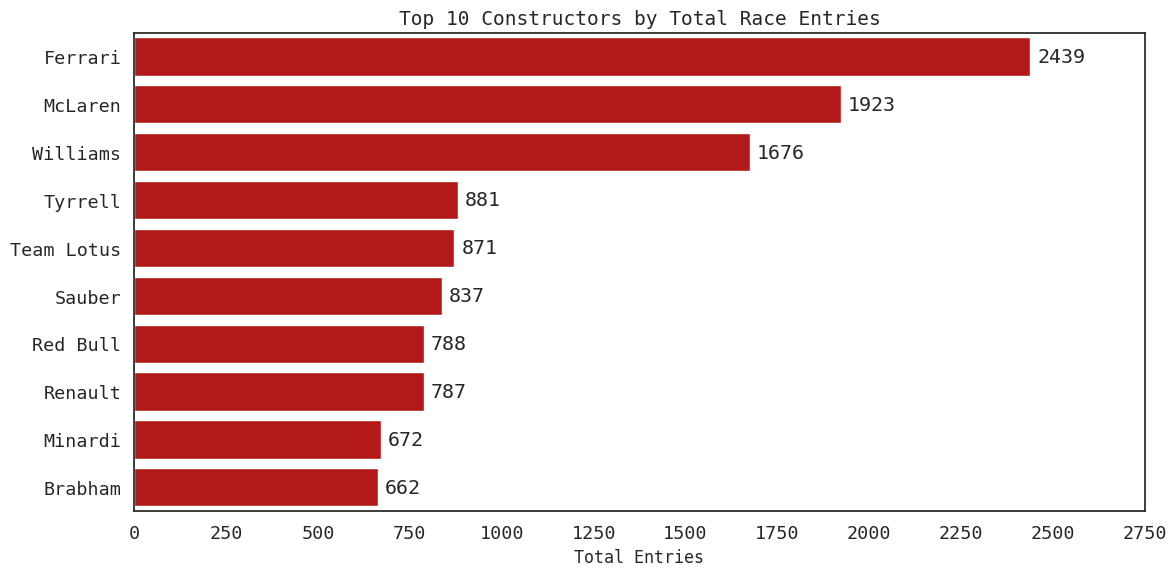

In [93]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_entries', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Race Entries')
ax.set_xlabel('Total Entries')
ax.set_ylabel('')
ax.set_xticks(np.arange(0, 3000, 250))
plt.tight_layout()
plt.show()

In [43]:
# Which constructors won the most races?

query = """ 
WITH constructor_wins AS (
        SELECT 
        c.constructorId,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId
),
ranked AS (
        SELECT 
        RANK() OVER(ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 10
        ORDER BY win_rank
"""

df = pd.read_sql(query, conn)
df

,win_rank,name,total_wins
0,1,Ferrari,249
1,2,McLaren,185
2,3,Mercedes,129
3,4,Red Bull,122
4,5,Williams,114
5,6,Team Lotus,45
6,7,Renault,35
7,8,Benetton,27
8,9,Tyrrell,23
9,9,Brabham,23


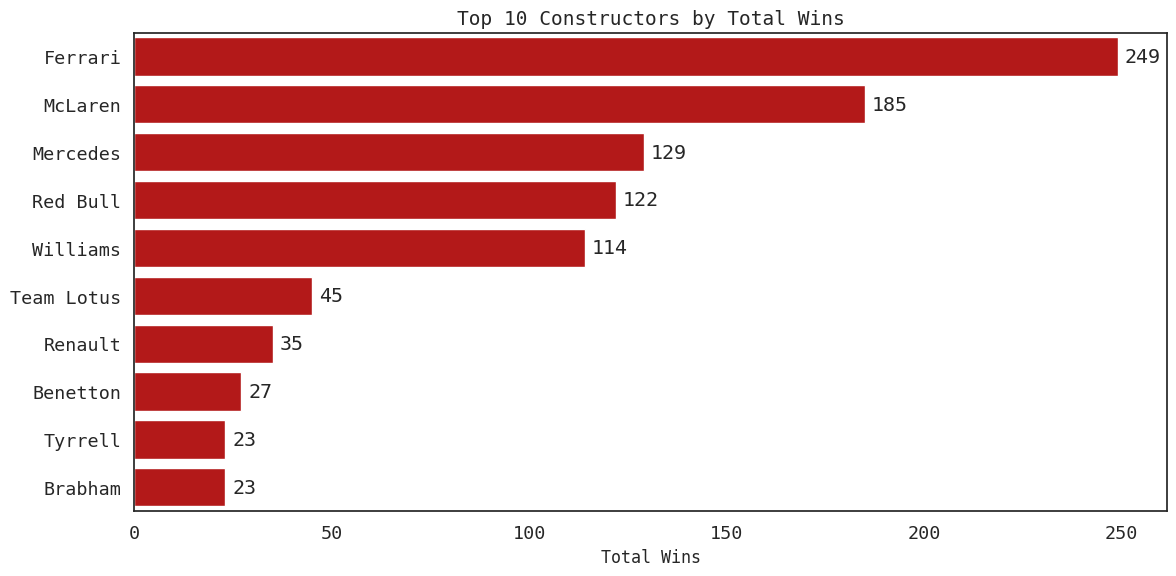

In [60]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_wins', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Wins')
ax.set_xlabel('Total Wins')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [122]:
# What is the distribution of race entries and wins per constructor per season?

query = """ 
        SELECT
        ra.year,
        c.name,
        COUNT(*) AS total_entries,
        SUM(CASE WHEN re.position = 1 THEN 1 ELSE 0 END) AS total_wins
        FROM results re
        JOIN constructors c ON c.constructorId = re.constructorId
        JOIN races ra ON ra.raceId = re.raceId
        GROUP BY re.constructorId, ra.year
"""


df = pd.read_sql(query, conn)
df

,year,name,total_entries,total_wins
0,1968,McLaren,2,0
1,1971,McLaren,27,0
2,1972,McLaren,25,1
3,1973,McLaren,35,3
4,1974,McLaren,46,4
...,...,...,...,...
1106,2021,Alpine F1 Team,44,1
1107,2022,Alpine F1 Team,44,0
1108,2023,Alpine F1 Team,44,0
1109,2024,Alpine F1 Team,48,0


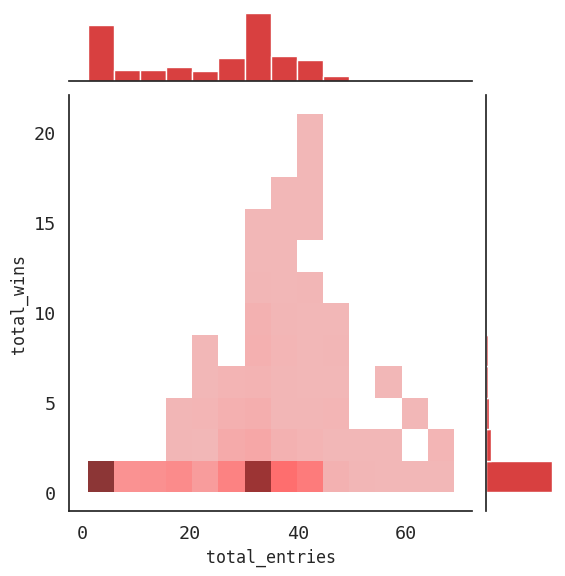

In [123]:
sns.jointplot(data=df, x='total_entries',y='total_wins',kind='hist')

In [61]:
# Which constructors dominated (in terms of total_wins) each decade of Formula 1?

query = """ 
WITH constructor_wins AS (
        SELECT 
        (ra.year / 10) * 10 AS decade,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId, decade
),
ranked AS (
        SELECT 
        decade,
        RANK() OVER(PARTITION BY decade ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 3
        ORDER BY decade, win_rank
"""

df = pd.read_sql(query, conn)
df

,decade,win_rank,name,total_wins
0,1950,1,Ferrari,30
1,1950,2,Alfa Romeo,11
2,1950,3,Vanwall,10
3,1960,1,Lotus-Climax,22
4,1960,2,Ferrari,13
5,1960,3,BRM,12
6,1970,1,Ferrari,37
7,1970,2,Team Lotus,35
8,1970,3,Tyrrell,21
9,1980,1,McLaren,56


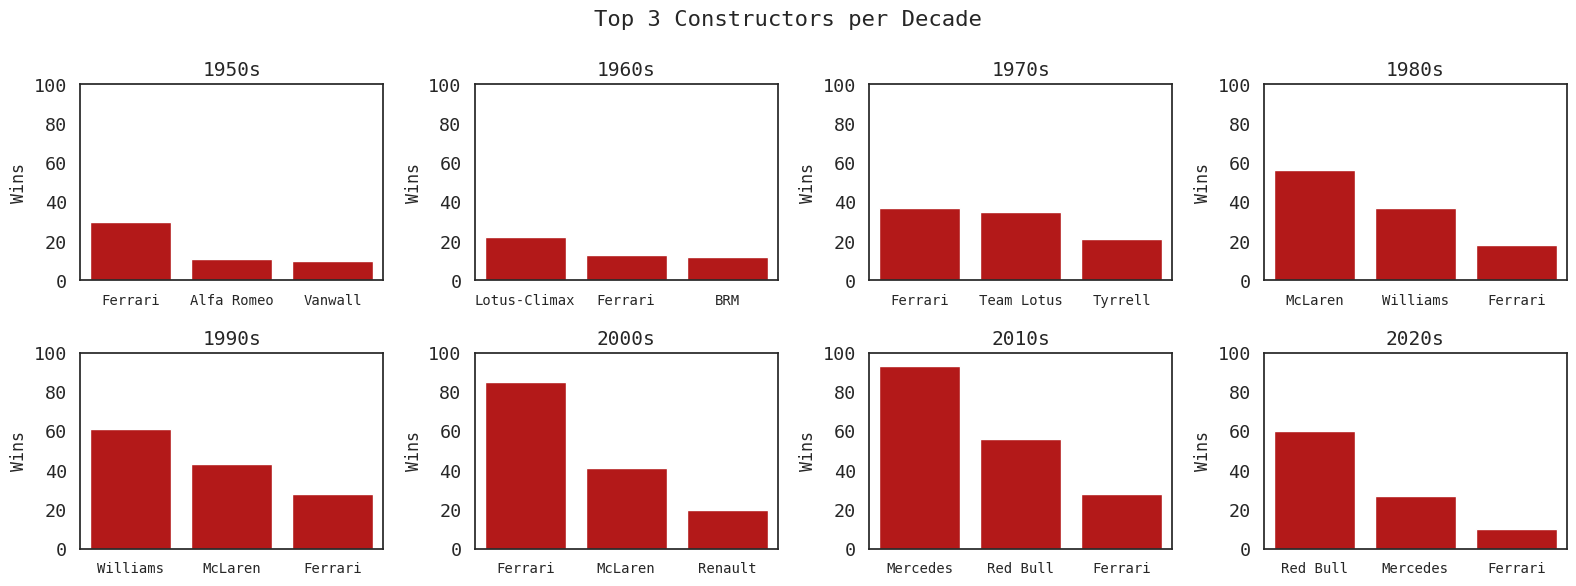

In [88]:
decades = df['decade'].unique()

fig, axes = plt.subplots(2, 4, figsize=(16,6))
axes = axes.flatten()
ticks = np.arange(0,120,20)

for i, decade in enumerate(sorted(decades)):
    decade_df = df[df['decade'] == decade]
    sns.barplot(data=decade_df, x='name', y='total_wins', ax=axes[i])
    axes[i].set_title(f'{decade}s')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Wins')
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].set_yticks(ticks)

plt.suptitle('Top 3 Constructors per Decade', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Greatest Drivers

In [128]:
# Who are the all-time top 10 drivers by points, wins and podiums? 

query = """ 
WITH drivers_result_info AS(
       SELECT 
       d.driverId,
       d.forename,
       d.surname,
       re.points,
       CASE re.position
              WHEN 1 THEN 1
              ELSE 0
       END AS win,
       CASE 
              WHEN re.position BETWEEN 1 AND 3 THEN 1
              ELSE 0
       END AS podium
       FROM drivers d 
       INNER JOIN results re ON d.driverId = re.driverId
)
       SELECT
       RANK() OVER(ORDER BY SUM(points) DESC) AS rank,
       forename || ' ' || surname AS best_driver,
       SUM(points) AS total_points,
       SUM(win) AS total_wins,
       SUM(podium) AS total_podiums
       FROM drivers_result_info
       GROUP BY driverId
       ORDER BY rank
       LIMIT 10
"""

df = pd.read_sql(query, conn)
df

,rank,best_driver,total_points,total_wins,total_podiums
0,1,Lewis Hamilton,4820.5,105,220
1,2,Sebastian Vettel,3098.0,53,173
2,3,Max Verstappen,2912.5,63,122
3,4,Fernando Alonso,2329.0,32,183
4,5,Kimi Räikkönen,1873.0,21,170
5,6,Valtteri Bottas,1788.0,10,148
6,7,Nico Rosberg,1594.5,23,99
7,8,Sergio Pérez,1585.0,6,126
8,9,Michael Schumacher,1566.0,91,176
9,10,Charles Leclerc,1363.0,8,62


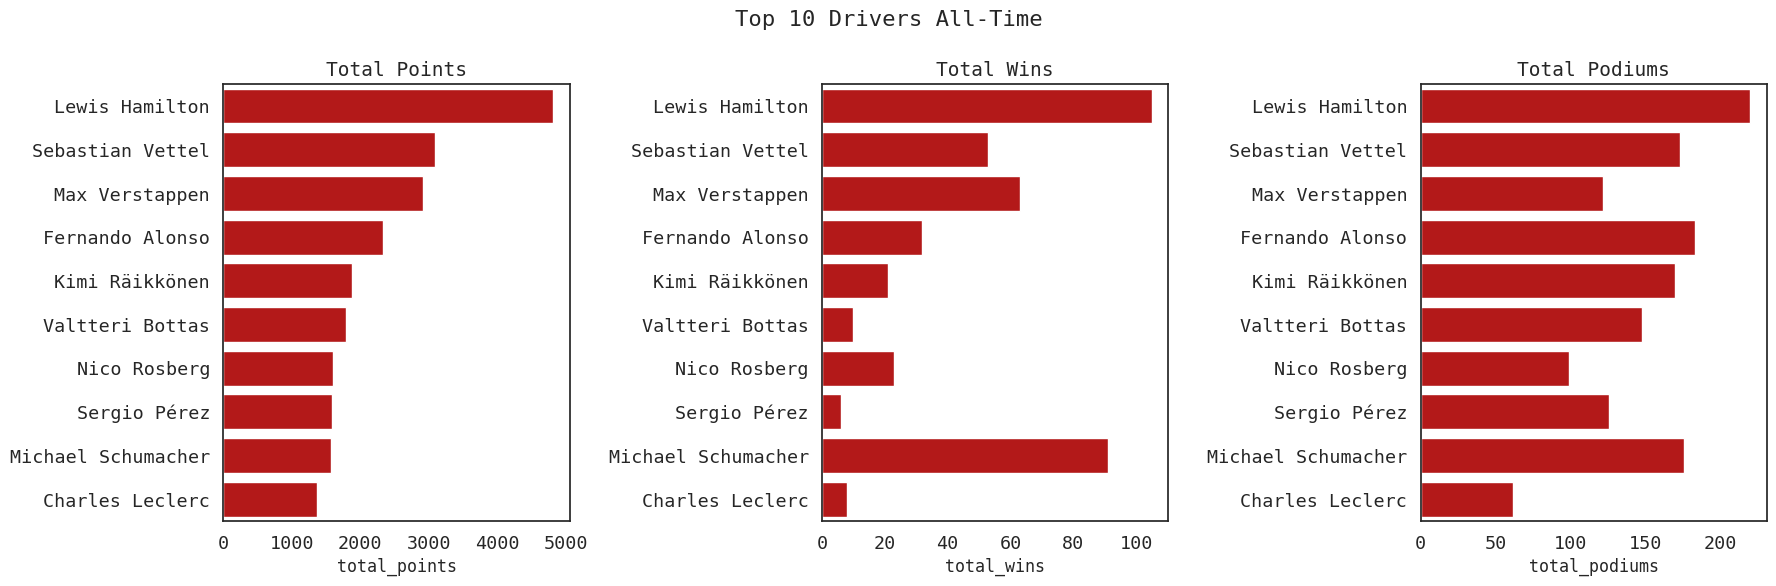

In [130]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df, y='best_driver', x='total_points', ax=ax1)
ax1.set_title('Total Points')
ax1.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_wins', ax=ax2)
ax2.set_title('Total Wins')
ax2.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_podiums', ax=ax3)
ax3.set_title('Total Podiums')
ax3.set_ylabel('')

plt.suptitle('Top 10 Drivers All-Time', fontsize=16)
plt.tight_layout()
plt.show()

In [147]:
# How did the top 5 drivers accumulate points throughout their careers?

query = """ 
WITH top_5_drivers AS(
        SELECT 
        d.driverId,
        d.forename,
        d.surname,
        RANK() OVER(ORDER BY SUM(re.points) DESC) AS rank,
        SUM(re.points) as total_points
        FROM drivers d 
        INNER JOIN results re ON d.driverId = re.driverId
        GROUP BY d.driverID
        ORDER BY total_points DESC
        LIMIT 5
), points_and_dates AS(
        SELECT
        t.forename,
        t.surname,
        t.rank,
        year,
        SUM(SUM(re.points)) OVER(PARTITION BY t.driverId ORDER BY year ASC) AS accumulated_points
        FROM top_5_drivers t 
        INNER JOIN results re ON t.driverId = re.driverId
        INNER JOIN races ra ON ra.raceId = re.raceId
        GROUP BY t.driverId, year
)
        SELECT
        forename || ' ' || surname AS driver,
        year,
        accumulated_points
        FROM points_and_dates
        ORDER BY rank, year
        
"""

df = pd.read_sql(query, conn)
df

,driver,year,accumulated_points
0,Lewis Hamilton,2007,109.0
1,Lewis Hamilton,2008,207.0
2,Lewis Hamilton,2009,256.0
3,Lewis Hamilton,2010,496.0
4,Lewis Hamilton,2011,723.0
...,...,...,...
79,Kimi Räikkönen,2017,1565.0
80,Kimi Räikkönen,2018,1816.0
81,Kimi Räikkönen,2019,1859.0
82,Kimi Räikkönen,2020,1863.0


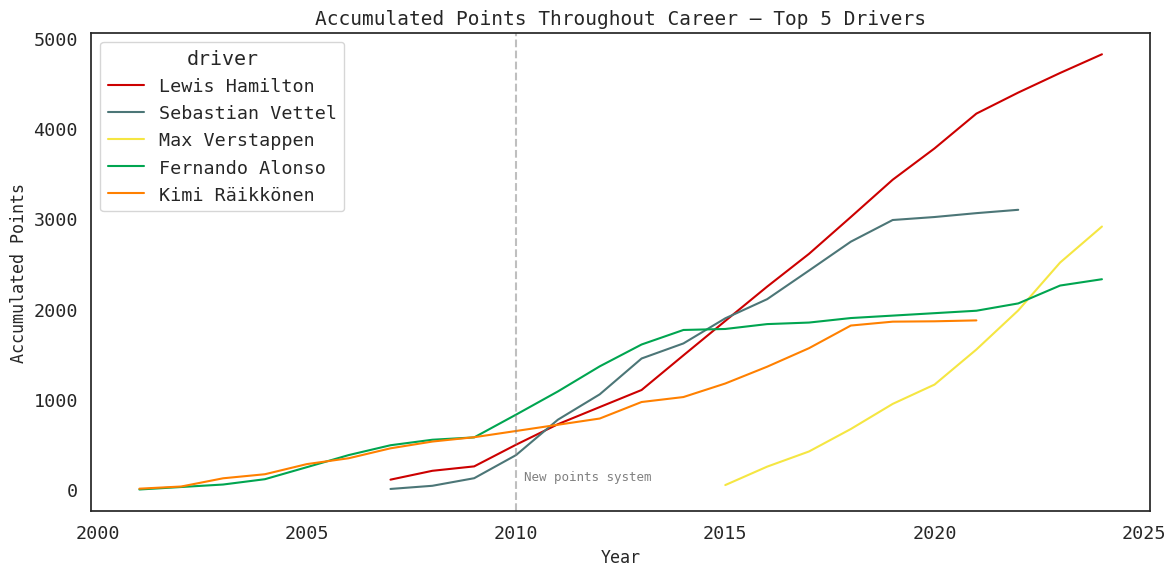

In [151]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='year', y='accumulated_points', hue='driver', ax=ax)
ax.set_title('Accumulated Points Throughout Career — Top 5 Drivers')
ax.set_xlabel('Year')
ax.set_ylabel('Accumulated Points')
ax.axvline(x=2010, color='gray', linestyle='--', alpha=0.5)
ax.text(2010.2, 100, 'New points system', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

Note: In 2010, F1 introduced a new points system  
This explains the steeper accumulation curves after 2010 for all drivers.

In [158]:
# Which nationalities have the most points and who were their most succesful drivers?

query = """ 
WITH best_nationalities AS(
    SELECT 
    d.nationality,
    SUM(re.points) as nationality_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY nationality
    ORDER BY nationality_points DESC
    LIMIT 10
), drivers_total_points AS(
    SELECT 
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    b.nationality,
    b.nationality_points,
    d.forename || ' ' || d.surname as best_driver,
    d.driver_points as best_driver_total_points
    FROM best_nationalities b
    INNER JOIN drivers_total_points d ON b.nationality=d.nationality
    AND (d.driver_points,d.nationality) IN 
    (     
        SELECT
        MAX(driver_points),
        nationality
        FROM drivers_total_points
        GROUP BY nationality
    )
    ORDER BY nationality_points DESC
        """


df = pd.read_sql(query, conn)
df

,nationality,nationality_points,best_driver,best_driver_total_points
0,British,11908.64,Lewis Hamilton,4820.5
1,German,7988.50,Sebastian Vettel,3098.0
2,Finnish,4388.50,Kimi Räikkönen,1873.0
3,French,3636.33,Alain Prost,798.5
4,Spanish,3614.50,Fernando Alonso,2329.0
5,Brazilian,3423.00,Felipe Massa,1167.0
6,Australian,3188.50,Daniel Ricciardo,1320.0
7,Dutch,2941.50,Max Verstappen,2912.5
8,Italian,2040.66,Riccardo Patrese,281.0
9,Mexican,1679.00,Sergio Pérez,1585.0


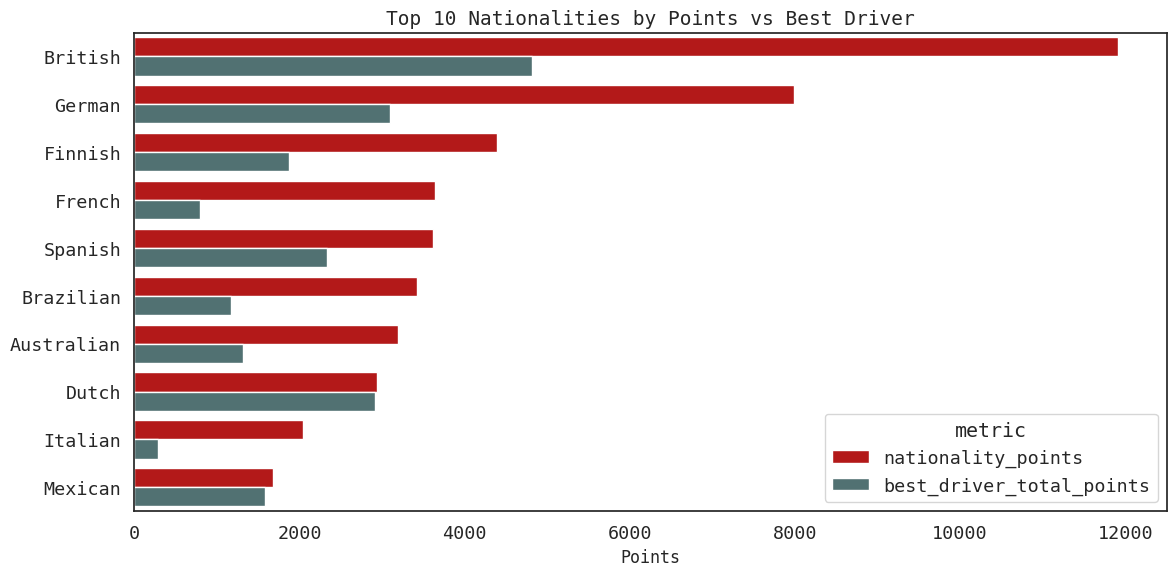

In [160]:
df_melted = df.melt(id_vars=['nationality', 'best_driver'],
                    value_vars=['nationality_points', 'best_driver_total_points'],
                    var_name='metric',
                    value_name='value')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_melted, y='nationality', x='value', hue='metric', ax=ax)
ax.set_title('Top 10 Nationalities by Points vs Best Driver')
ax.set_xlabel('Points')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [38]:
# Which drivers scored above average points for their nationality?

query = """
WITH drivers_total_points AS(
    SELECT
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(re.points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    forename || ' ' || surname AS driver_name,
    nationality,
    driver_points
    FROM drivers_total_points d
    WHERE driver_points > (
        SELECT AVG(driver_points)
        FROM drivers_total_points d2
        WHERE d2.nationality = d.nationality
    )
    ORDER BY nationality, driver_points DESC
"""

pd.read_sql(query, conn)

,driver_name,nationality,driver_points
0,Mario Andretti,American,180.0
1,Dan Gurney,American,133.0
2,Richie Ginther,American,107.0
3,Phil Hill,American,98.0
4,Eddie Cheever,American,70.0
...,...,...,...
137,Jo Siffert,Swiss,68.0
138,Sébastien Buemi,Swiss,29.0
139,Marc Surer,Swiss,17.0
140,Alexander Albon,Thai,238.0


## 4. Circuits

In [39]:
# Which circuits are the most and the least dangerous? (R= Retired)
# We ignore circuits with less than a two hundred entries where DNF can be unstable

query = """ 
WITH circuit_retired_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    COUNT(*) FILTER(WHERE re.positionText='R') AS retired,
    COUNT(*) AS all_entries
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries
        FROM circuit_retired_stats
        ORDER BY dnf_rate DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries
        FROM circuit_retired_stats
        ORDER BY dnf_rate ASC
        LIMIT 10 )
    ORDER BY dnf_rate DESC
"""

pd.read_sql(query, conn)

,circuitRef,name,category,dnf_rate,retired,all_entries
0,adelaide,Adelaide Street Circuit,most dangerous,47.12,147,312
1,brands_hatch,Brands Hatch,most dangerous,45.45,170,374
2,long_beach,Long Beach,most dangerous,45.00,99,220
3,zolder,Zolder,most dangerous,43.62,123,282
4,jacarepagua,Autódromo Internacional Nelson Piquet,most dangerous,42.66,122,286
5,galvez,Autódromo Juan y Oscar Gálvez,most dangerous,41.96,188,448
6,kyalami,Kyalami,most dangerous,41.90,212,506
7,reims,Reims-Gueux,most dangerous,40.94,104,254
8,indianapolis,Indianapolis Motor Speedway,most dangerous,40.84,234,573
9,watkins_glen,Watkins Glen,most dangerous,40.21,195,485


In [40]:
# Which circuits produce the most and the least overtakes on average?
# We ignore circuits with less than two hundred entries where results can be unstable

query = """ 
WITH circuit_overtake_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    ROUND(AVG(ABS(re.grid - re.positionOrder)), 2) AS avg_position_change,
    COUNT(*) AS all_entries
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most overtakes' AS category,
        avg_position_change,
        all_entries
        FROM circuit_overtake_stats
        ORDER BY avg_position_change DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least overtakes' AS category,
        avg_position_change,
        all_entries
        FROM circuit_overtake_stats
        ORDER BY avg_position_change ASC
        LIMIT 10 )
    ORDER BY category DESC, avg_position_change DESC
"""

pd.read_sql(query, conn)

,circuitRef,name,category,avg_position_change,all_entries
0,zolder,Zolder,most overtakes,9.97,282
1,jacarepagua,Autódromo Internacional Nelson Piquet,most overtakes,9.96,286
2,long_beach,Long Beach,most overtakes,9.50,220
3,jarama,Jarama,most overtakes,9.47,236
4,adelaide,Adelaide Street Circuit,most overtakes,9.05,312
5,jerez,Circuito de Jerez,most overtakes,8.83,204
6,estoril,Autódromo do Estoril,most overtakes,8.31,367
7,indianapolis,Indianapolis Motor Speedway,most overtakes,8.28,573
8,brands_hatch,Brands Hatch,most overtakes,8.24,374
9,ricard,Circuit Paul Ricard,most overtakes,7.95,481
